In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("stock_data.csv")

In [3]:
df

,Date,Close
0,2023-01-02,151.20
1,2023-01-03,150.96
2,2023-01-04,152.51
3,2023-01-05,156.11
4,2023-01-06,155.64
...,...,...
255,2023-12-25,171.00
256,2023-12-26,174.37
257,2023-12-27,172.61
258,2023-12-28,173.85


#### Task 1

In [4]:
# Convert string to datetime
df["Date"] = pd.to_datetime(df["Date"])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    260 non-null    datetime64[us]
 1   Close   260 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 4.2 KB


In [6]:
# Set as index
df = df.set_index("Date")

In [7]:
# Sort Index
df = df.sort_index()

In [8]:
df.head()

,Close
Date,
2023-01-02,151.20
2023-01-03,150.96
2023-01-04,152.51
2023-01-05,156.11
2023-01-06,155.64


---

#### Task 2

In [9]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()

In [11]:
df["SMA_20"].head(25)

Date
2023-01-02         NaN
2023-01-03         NaN
2023-01-04         NaN
2023-01-05         NaN
2023-01-06         NaN
2023-01-09         NaN
2023-01-10         NaN
2023-01-11         NaN
2023-01-12         NaN
2023-01-13         NaN
2023-01-16         NaN
2023-01-17         NaN
2023-01-18         NaN
2023-01-19         NaN
2023-01-20         NaN
2023-01-23         NaN
2023-01-24         NaN
2023-01-25         NaN
2023-01-26         NaN
2023-01-27    154.3325
2023-01-30    154.1320
2023-01-31    153.9225
2023-02-01    153.6465
2023-02-02    153.0385
2023-02-03    152.3990
Name: SMA_20, dtype: float64

---

#### Task 3 

In [15]:
df["Daily_Return"] = df["Close"].pct_change() * 100
df["Daily_Return"] = df["Daily_Return"].round(2)

In [16]:
df["Daily_Return"]

Date
2023-01-02     NaN
2023-01-03   -0.16
2023-01-04    1.03
2023-01-05    2.36
2023-01-06   -0.30
              ... 
2023-12-25   -0.67
2023-12-26    1.97
2023-12-27   -1.01
2023-12-28    0.72
2023-12-29    1.22
Name: Daily_Return, Length: 260, dtype: float64

#### Task 4

In [19]:
monthly_max = df["Close"].resample("ME").max()

print(monthly_max)

Date
2023-01-31    161.23
2023-02-28    146.99
2023-03-31    136.03
2023-04-30    142.25
2023-05-31    139.66
2023-06-30    144.18
2023-07-31    138.13
2023-08-31    147.83
2023-09-30    156.14
2023-10-31    171.52
2023-11-30    174.29
2023-12-31    176.04
Freq: ME, Name: Close, dtype: float64


#### Task 5

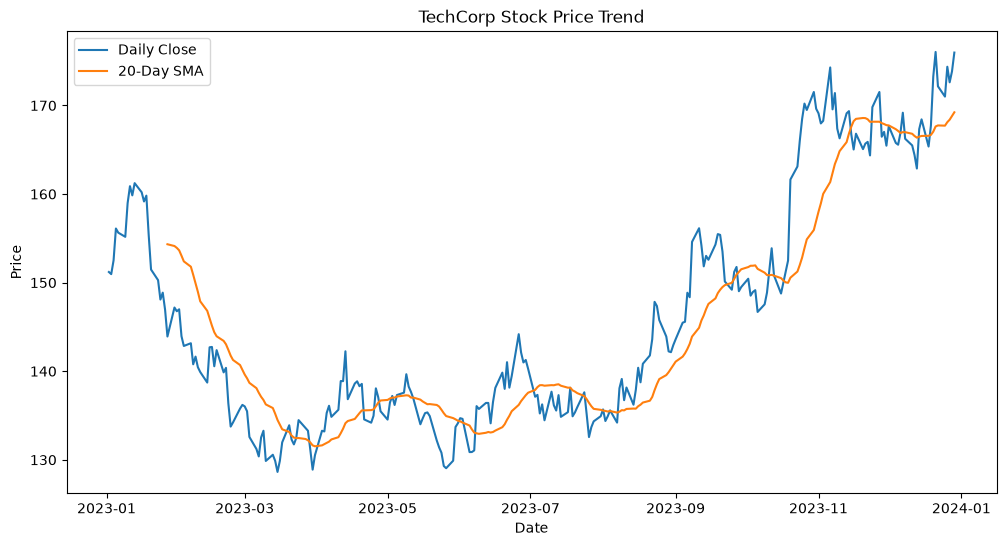

In [21]:
plt.figure(figsize=(12, 6))

# Plot close price
plt.plot(df.index, df["Close"], label="Daily Close")

# Plot SMA
plt.plot(df.index, df["SMA_20"], label="20-Day SMA")

plt.title("TechCorp Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()